In [1]:
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [2]:
import os

# Get the parent directory of the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# List all directories in the parent directory
directories = [d for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]

# Filter directories that start with "Eplus-env-2024-04-29_cambridge"
filtered_directories = [d for d in directories if d.startswith("Eplus-env-2024-04")]


In [3]:
import pandas as pd

locations = ["cambridge", "newcastle", "southampton", "manchester", "london"]
controls = ["manual", "eco"]
values = {}

# Assuming 'filtered_directories' is a pre-defined list of directory names
for location in locations:
    values[location] = {}
    for control in controls:
        values[location][control] = {}
        for i in range(5):
            case = "case_" + str(i)
            values[location][control][case] = []
            for dir in filtered_directories:
                # Check if both control and case are in the directory name
                if location in dir and control in dir and case in dir:
                    progress_path = "/workspaces/CUBES/" + dir + "/progress.csv"
                    df = pd.read_csv(progress_path)
                    # Assuming 'cumulative_emissions' is a column in your CSV
                    values[location][control][case].append(df["cumulative_emissions"].values[0])



In [4]:
values

{'cambridge': {'manual': {'case_0': [2361.5910508460784,
    2285.673182843778,
    2122.6120596885203,
    2395.8118010242506,
    2111.635406456405],
   'case_1': [2463.461868785403,
    2214.601181225188,
    2437.354859139966,
    2122.3974979687982,
    1915.052773779372],
   'case_2': [1571.8894046554449,
    1371.385463961835,
    1720.357617455567,
    1740.4677040052106,
    1443.3581503592302],
   'case_3': [701.4776257213564,
    705.2006874627335,
    703.2707187234246,
    745.5026843616354,
    713.534059513162],
   'case_4': [304.245752048407,
    305.1125187335989,
    289.028535624366,
    313.06117706101537,
    318.0607905030711]},
  'eco': {'case_0': [1791.2112162487335,
    1797.6764578574223,
    1730.366520946211,
    1746.3749336196506,
    1647.4567728009688],
   'case_1': [1490.94137020121,
    1575.0692672586033,
    1612.305903019626,
    1558.718906949961,
    1618.0050753589194],
   'case_2': [1226.7118476496753,
    1182.9935347170886,
    1221.0514515226

In [9]:
values_df = pd.DataFrame(values)

values_df.to_csv("results.csv")

In [7]:
values_df

,cambridge,newcastle,southampton,manchester,london
manual,"{'case_0': [2361.5910508460784, 2285.673182843...","{'case_0': [2301.315162623988, 2482.8001656846...","{'case_0': [1963.929934781112, 1957.5022670536...","{'case_0': [2661.400132707966, 2037.9079469920...","{'case_0': [2328.4246121280144, 2202.184020871..."
eco,"{'case_0': [1791.2112162487335, 1797.676457857...","{'case_0': [1887.8567383914456, 1778.726404176...","{'case_0': [1520.5559587684495, 1612.004097003...","{'case_0': [2003.1602553866155, 2015.368764313...","{'case_0': [1571.98430465058, 1671.69655691144..."


In [48]:
import geopandas as gpd
import matplotlib.pyplot as plt
import re

# Load GeoJSON file
geojson_path = "/workspaces/CUBES/progress_summary/england.geojson"
gdf = gpd.read_file(geojson_path)
# Filter regions in England


# Filter regions in England or London
eng_gdf = gdf[gdf["nuts118nm"].str.contains(r'England|London|Yorkshire and The Humber', flags=re.IGNORECASE, regex=True)]



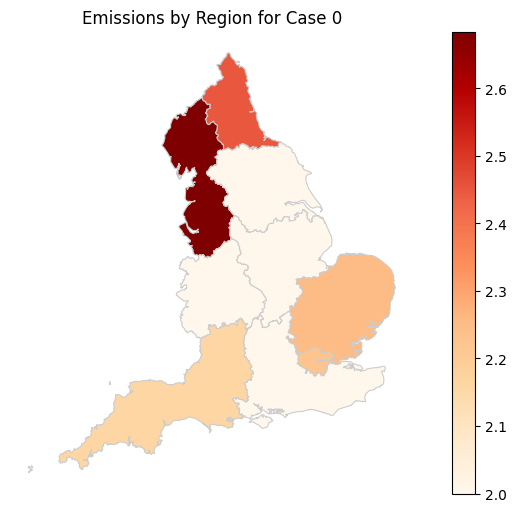

In [54]:

# Sample emissions reduction potential data
data = {
    'Region': ['North East (England)',
               'North West (England)',
               'East Midlands (England)',
               "West Midlands (England)",
               "East of England",
               "South East (England)",
               "South West (England)",
               "London",
               "Yorkshire and The Humber"],

    'Emissions': [2.44631,
                  2.68395,
                  2.000,
                  2.000,
                  2.25546,
                  2.000,
                  2.16167,
                  2.22575,
                  2.000]  # Emissions reduction potential for each region
}

# Convert emissions reduction potential data to DataFrame
df = pd.DataFrame(data)

# Merge data with GeoDataFrame
merged = gdf.merge(df, how='left', left_on='nuts118nm', right_on='Region')

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
merged.plot(column='Emissions', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Emissions by Region for Case 0')
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.show()


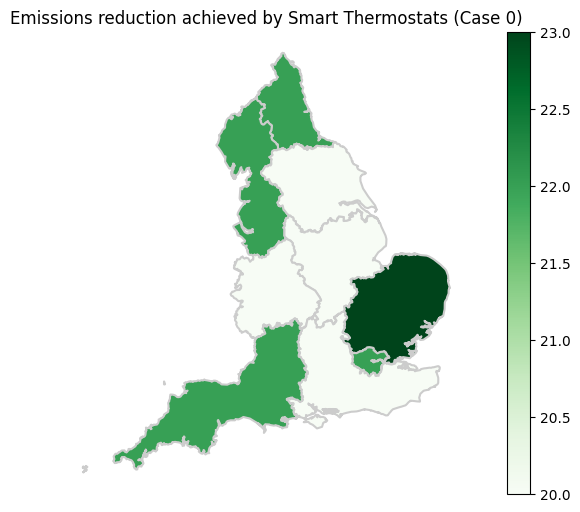

In [55]:

# Sample emissions reduction potential data
data = {
    'Region': ['North East (England)',
               'North West (England)',
               'East Midlands (England)',
               "West Midlands (England)",
               "East of England",
               "South East (England)",
               "South West (England)",
               "London",
               "Yorkshire and The Humber"],

    'Emissions reduction': [22,
                  22,
                  20.000,
                  20.000,
                  23,
                  20.000,
                  22,
                  22,
                  20.000]  # Emissions reduction potential for each region
}

# Convert emissions reduction potential data to DataFrame
df = pd.DataFrame(data)

# Merge data with GeoDataFrame
merged = gdf.merge(df, how='left', left_on='nuts118nm', right_on='Region')

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
merged.plot(column='Emissions reduction', cmap='Greens', linewidth=1.5, ax=ax, edgecolor='0.8', legend=True)
plt.title('Emissions reduction achieved by Smart Thermostats (Case 0)')
ax.set_xticks([])
ax.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.show()


In [74]:
averages = {}

for location, controls in values.items():
    averages[location] = {}
    for control, cases in controls.items():
        averages[location][control] = {}
        for case, values in cases.items():
            average_value = sum(values) / len(values)
            averages[location][control][case] = average_value

In [75]:
averages

{'cambridge': {'manual': {'case_0': 2255.4647001718063,
   'case_1': 2230.5736361797453,
   'case_2': 1569.4916680874576,
   'case_3': 713.7971551564624,
   'case_4': 305.9017547940917},
  'eco': {'case_0': 1742.6171802945973,
   'case_1': 1571.008104557664,
   'case_2': 1194.2097293328015,
   'case_3': 602.1193577176178,
   'case_4': 265.219132341615}},
 'newcastle': {'manual': {'case_0': 2446.3142163927255,
   'case_1': 2227.155558414185,
   'case_2': 1697.273359082858,
   'case_3': 777.9577681313312,
   'case_4': 330.20209539084016},
  'eco': {'case_0': 1880.7997500529814,
   'case_1': 1693.9840195683614,
   'case_2': 1291.4486197152594,
   'case_3': 654.4335939961336,
   'case_4': 283.4531544908758}},
 'southampton': {'manual': {'case_0': 2161.665796338959,
   'case_1': 1918.733356244867,
   'case_2': 1552.3183443693708,
   'case_3': 636.0777924651254,
   'case_4': 264.0354862981614},
  'eco': {'case_0': 1606.720427619101,
   'case_1': 1402.938271300411,
   'case_2': 1089.661336609